# Kestrel ML — Adaptive Valuation Thresholds

**Goal:** "Is this stock's current valuation unusually low compared to how its own valuation normally behaves?"

Four sittings:
1. **Get data and LOOK at it** (this section) — pull history, plot it, eyeball where "today" sits.
2. Statistics version — rolling z-score / percentile (*I write the math*).
3. ML version — Isolation Forest (*I write the fit/score*).
4. Service wrapper — `valuation_anomaly(ticker) -> dict`.

## Sitting 1 — Get data and LOOK at it

**Data reality:** yfinance gives clean *daily price* history, but historical *fundamental ratios* (P/E over time) are not available as a time series — `.info` only holds a single current snapshot. So we learn the technique on price data first (price vs its own moving-average distribution), and swap in fundamentals later once the method is understood.

The question becomes the same shape either way: **is today's value unusual vs its own recent history?**

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TICKER = "AAPL"
WINDOW = 252  # ~1 trading year; the "normal behavior" lookback we'll use later

In [5]:
# --- Pull data (boilerplate) ---
raw = yf.Ticker(TICKER).history(period="2y", auto_adjust=True)

# Keep just the closing price, drop timezone from the index for clean plotting.
df = raw[["Close"]].copy()
df.index = df.index.tz_localize(None)

print(f"{TICKER}: {len(df)} trading days, {df.index.min().date()} -> {df.index.max().date()}")
print(f"NaNs in Close: {df['Close'].isna().sum()}")
df.tail()

AAPL: 501 trading days, 2024-07-01 -> 2026-06-30
NaNs in Close: 0


,Close
Date,
2026-06-24,293.079987
2026-06-25,275.149994
2026-06-26,283.779999
2026-06-29,281.739990
2026-06-30,289.359985


### Look at it

Plot the price, overlay its rolling mean (the "normal" line), and mark today. Before computing any z-score, just *eyeball* it: does today look far from the average band, or normal?

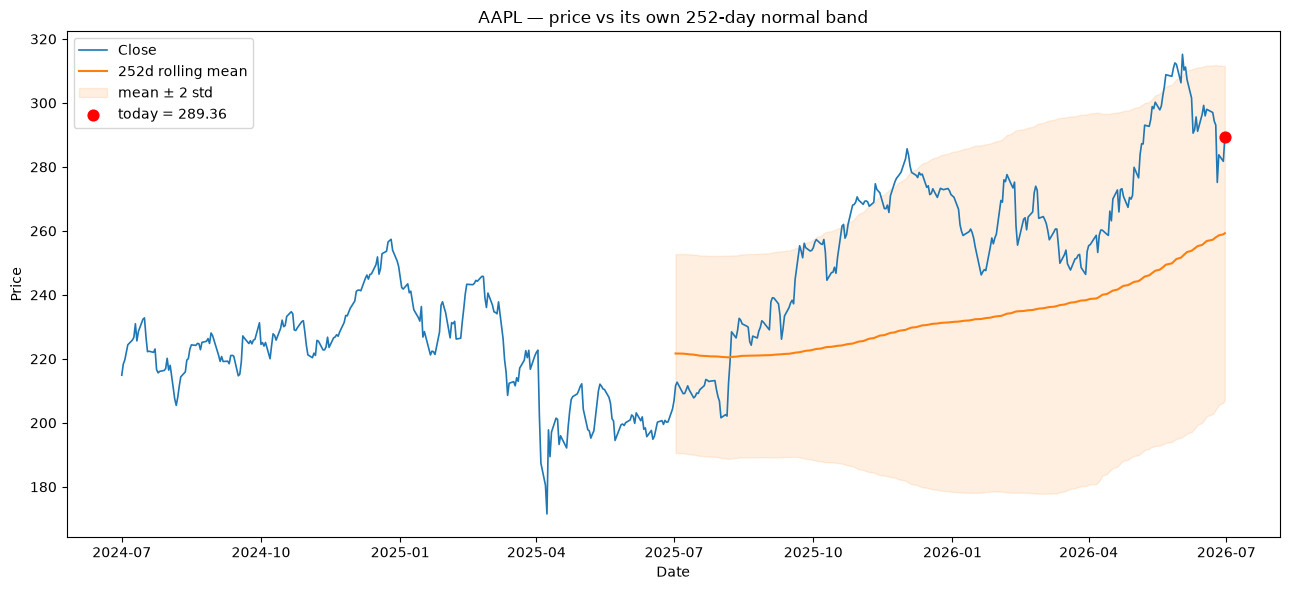

In [14]:
# --- Plot (you may write plotting code) ---
# rolling mean/std here are ONLY for a visual reference band -- the anomaly math
# (z-score / percentile) is Sitting 2 and I write that myself.

# For roughly bell-shaped (normal) data, there's a well-known rule of thumb:
# about 68% of values fall within ±1 std
# about 95% fall within ±2 std
# about 99.7% fall within ±3 std

roll_mean = df["Close"].rolling(WINDOW).mean()
roll_std = df["Close"].rolling(WINDOW).std()

today_date = df.index[-1]
today_price = df["Close"].iloc[-1]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df.index, df["Close"], label="Close", color="#1f77b4", lw=1.2)
ax.plot(df.index, roll_mean, label=f"{WINDOW}d rolling mean", color="#ff7f0e", lw=1.5)
ax.fill_between(df.index, roll_mean - 2 * roll_std, roll_mean + 2 * roll_std,
                color="#ff7f0e", alpha=0.12, label="mean ± 2 std")
ax.scatter([today_date], [today_price], color="red", zorder=5, s=60,
           label=f"today = {today_price:.2f}")
ax.set_title(f"{TICKER} — price vs its own {WINDOW}-day normal band")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

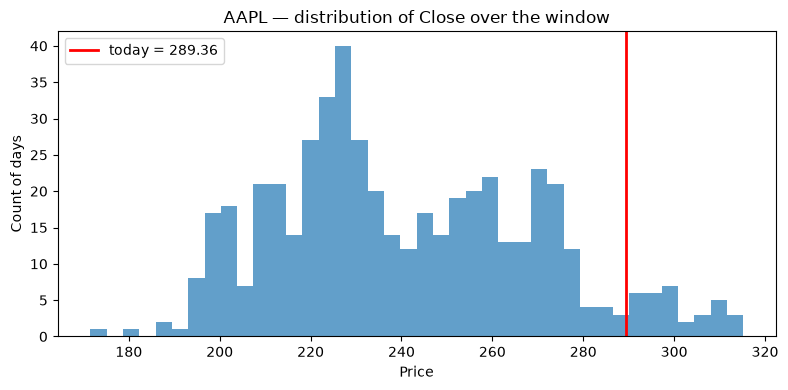

In [13]:
# --- Quick distribution view: where does today sit in the histogram of prices? ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["Close"].dropna(), bins=40, color="#1f77b4", alpha=0.7)
ax.axvline(today_price, color="red", lw=2, label=f"today = {today_price:.2f}")
ax.set_title(f"{TICKER} — distribution of Close over the window")
ax.set_xlabel("Price")
ax.set_ylabel("Count of days")
ax.legend()
plt.tight_layout()
plt.show()

**Eyeball check (write your read here):**

- Is today inside or outside the ±2 std band?
- On the histogram, is today near the middle (normal) or out in a tail (unusual)?
- Gut call *before* any math: does today look anomalous? _(fill in)_

Yes.
Middle of middle and tail.
No.

---
## Sitting 2 — Statistics version (I write this)

Rolling mean + std over the 252-day window → z-score and percentile of today.

*TODO (me): fill in the z-score and percentile math.*

### 📐 The math behind it, explained simply

You only need **four ideas**. Nothing here is harder than "average."

#### 1. Mean = the "normal" line
The mean is just the average of the last 252 days. It's your best one-number answer to *"what's normal for this stock?"*

> If a kid's test scores are 80, 90, 85, 70, 100 → the mean is 85. "Normal" for this kid is around 85.

#### 2. Standard deviation (std) = "how much does it usually wiggle?"
The mean tells you the center, but not how *spread out* things are. Two stocks can both average \$100, but one calmly sits at \$98–\$102 while the other swings \$60–\$140. Standard deviation is the single number that captures that spread — roughly, **the typical distance from the mean**.

> **How it's built (the intuition, not memorization):**
> 1. Take each day's distance from the mean.
> 2. *Square* those distances (this kills the minus signs so above/below don't cancel out, and it punishes big misses harder).
> 3. Average the squares, then take the square root to undo the squaring.
>
> The square-root at the end just puts you back into normal units (dollars), not "dollars²". That's the whole trick.

Small std = calm stock, tight band. Big std = jumpy stock, wide band. It's the width of that orange band on your plot.

#### 3. Z-score = "how many wiggles away from normal is today?"
This is the star of the show. It answers: *"today is far from average… but is that a LOT of far, or a normal amount of far?"*

$$z = \frac{\text{today} - \text{mean}}{\text{std}}$$

The top (today − mean) is the raw distance. Dividing by std **rescales that distance into units of 'typical wiggle.'**

> **Analogy:** being 10 cm taller than average is a big deal for adults (small wiggle) but nothing for a group of toddlers (huge wiggle). The z-score is "how many wiggles," so it's fair across calm and jumpy stocks.

Read it like this:
- **z = 0** → today is exactly average. Boring.
- **z = +1** → one wiggle above normal.
- **z = −2** → two wiggles *below* normal → unusually cheap. **This is the interesting one for us.**
- **|z| ≥ 2** is the classic "hmm, that's unusual" line (only ~5% of days land out there if things are bell-shaped).

Sign matters: **negative z = cheap vs its own norm**, which is exactly the buy-signal Kestrel cares about.

#### 4. Percentile = "out of 100 similar days, how many were cheaper than today?"
Z-score assumes a nice symmetric bell curve. Percentile doesn't assume anything — it just **ranks** today against every day in the window.

> "Today is at the **8th percentile**" = only 8% of the last 2 years were cheaper than right now. Today is near the cheap floor. That's the plain-English sentence Kestrel will show a user.

**Why compute both?** Z-score is one clean number and works great when the data is bell-shaped. Percentile is honest even when it isn't (stocks are often lopsided). If they *disagree*, that disagreement is itself a signal that the distribution is weird — and noticing that is real learning.

---
**So your two TODOs below are literally:**
- `z = (current − rolling_mean) / rolling_std`  ← one line
- `percentile = % of window values below current`  ← rank today in the history

That's it. The concepts above are the "why"; the code is short. Go write it. 💪

*(Shaky on any of these? Search StatQuest on YouTube for "standard deviation" or "z-score" — Josh Starmer explains them in ~5 min with pictures.)*


---
## Sitting 3 — ML version (I write the fit/score)

`sklearn.ensemble.IsolationForest`, compared against the z-score.

*TODO (me): fit + score + interpret.*

### 🌲 Isolation Forest, explained simply (don't read this until Sitting 3)

The z-score works on **one** number at a time. Isolation Forest is the upgrade: it finds points that are weird across **several** numbers at once (e.g. P/E *and* P/B together).

**The one idea:** *weird points are easy to isolate.*

> Imagine everyone in a room, and you play "20 questions" splitting them with random cuts: "left/right of this line? above/below that one?" A person standing in the middle of the crowd takes *many* cuts to fence off alone. A person standing alone in a corner gets fenced off in **one or two cuts**.
>
> **Anomaly = gets isolated in very few cuts.** That's the entire algorithm.

- It builds lots of random splitting-trees ("forest") and, for each point, measures the **average number of cuts to isolate it**.
- Few cuts → out on its own → **anomalous**. Many cuts → buried in the crowd → **normal**.
- **`contamination`** is the one knob you'll set: your guess at "what fraction of days are anomalies?" (e.g. `0.05` = expect ~5% weird). It just sets where the algorithm draws the anomaly/normal cutoff line.

**Why we compare it to the z-score:** on a single metric they should mostly agree. The payoff is with *two* metrics — Isolation Forest can flag a day where P/E looks fine and P/B looks fine, but the **combination** is unusual. A z-score on each one separately would miss that. Spotting where the two methods disagree, and explaining *why*, is the whole point of Sitting 3.

*(Canonical pattern + pictures: the scikit-learn "IsolationForest" / outlier-detection docs.)*


---
## Sitting 4 — Service wrapper

`valuation_anomaly(ticker) -> {percentile, z_score, is_anomaly, explanation}` — structure only; body calls the logic from sittings 2–3.